In [14]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal



In [15]:
class eqnState(TypedDict):
    a: int
    b: int
    c: int
    equation: str
    discriminant: float
    result: str


In [16]:
def show_eqn(state: eqnState):
    a = state["a"]
    b = state["b"]
    c = state["c"]    
    equation = f'({a})x2+({b})x+({c})'
    return {'equation':equation}


In [17]:
def discriminant(state: eqnState):
    a = state["a"]
    b = state["b"]
    c = state["c"]
    discriminant = b**2 - (4*a*c)

    return {'discriminant': discriminant}

In [18]:
def no_real_root(state: eqnState):
    result = f'No real roots'

    return {'result': result}

In [19]:
def real_root(state: eqnState):
    a = state["a"]
    b = state["b"]
    d = state["discriminant"]    
    root1 = (-b + d**0.5)/(2*a)
    root2 = (-b - d**0.5)/(2*a)

    result = f'The roots are {root1:.2f} and {root2:.2f}'

    return {'result': result}

In [20]:
def repeated_root(state: eqnState):
    a = state["a"]
    b = state["b"]
    root = (-b)/(2*a)

    result = f'Only repeating root is {root:.2f}'

    return {'result': result}

In [21]:
def check_condition(state: eqnState) -> Literal["real_root", "repeated_root", "no_real_root"]:

    if state['discriminant'] > 0:
        return "real_root"
    elif state['discriminant'] == 0:
        return "repeated_root"
    else:
        return "no_real_root"

In [22]:
graph = StateGraph(eqnState)
graph.add_node('show_eqn', show_eqn)
graph.add_node('discriminant', discriminant)
graph.add_node('no_real_root', no_real_root)
graph.add_node('real_root', real_root)
graph.add_node('repeated_root', repeated_root)

graph.add_edge(START, 'show_eqn')
graph.add_edge('show_eqn','discriminant')
graph.add_conditional_edges('discriminant', check_condition)
graph.add_edge('real_root', END)
graph.add_edge('repeated_root', END)
graph.add_edge('no_real_root', END)

In [23]:
workflow=graph.compile()

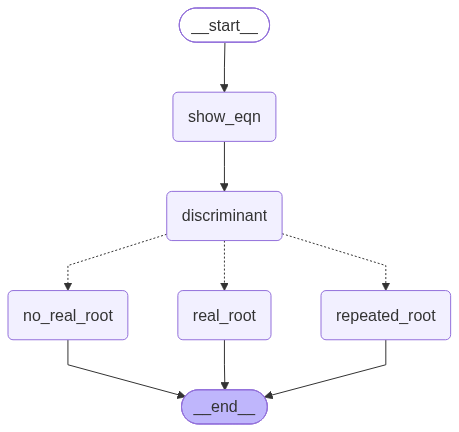

In [24]:
workflow

In [25]:
initial_state = {
    'a': 8, 
    'b': -16,
    'c': 5
}

final_state=workflow.invoke(initial_state)

In [26]:
print(f"Equation = {final_state['equation']}")
print(f"Discriminant = {final_state['discriminant']}")
print(f"Result = {final_state['result']}")

Equation = (8)x2+(-16)x+(5)
Discriminant = 96
Result = The roots are 1.61 and 0.39
